# Geo-Nexus v3.2 — P4b Maharashtra Few-Shot Adaptation | V6 final

This notebook implements the P4b / P-FS stage after the completed P3 OSCD supervised transfer and separately executed P4a zero-shot evaluation.

## Frozen P4b protocol

- P3 checkpoint: `sumit07125/geonexus-p3-oscd-artifacts`
- P4 evaluation source: `sumit07125/geonexus-mh-p4-eval-v3-2`
- MH-ADAPT: **30 human-reviewed patches**, used only for supervised few-shot adaptation
- MH-VAL: **30 human-reviewed patches**, used only for early stopping and threshold selection
- MH-TEST: **110 verified patches** = 40 Pune + 40 Satara + 30 Vidarbha
- Labels `255` are **ignore** and are never converted to no-change
- Each k starts from a **fresh copy of the same P3 checkpoint**
- P4b activates the SAR branch and trainable fusion gate
- Loss: masked BCE + Dice with deep-supervision weights `[1.0, 0.5, 0.25]` plus gate loss weight `0.05`
- Learning rates: optical encoder `5e-6`, SAR encoder `5e-6`, decoder `2e-5`, gate `1e-4`
- Early stopping: patience `8`, execution cap `30` epochs
- Training uses FP32; AMP/FP16 is disabled for the final stable protocol
- Prediction path uses GPU FP32 with an exact CPU float64 retry only when a GPU batch is non-finite

## Requested six-point few-shot curve

The original verified P4b protocol used `k ∈ {5, 10, 20, 30}`. This final revision adds **k=2 and k=3** as two extra low-shot points.

The choice is constrained by the source data: MH-ADAPT contains exactly 30 labelled adaptation patches, so values above 30 would require changing the frozen split or reusing validation/test data and would therefore violate the evaluation protocol. The added k=2 and k=3 points enrich the low-data regime without contaminating MH-VAL or MH-TEST.

Final k set:

`k ∈ {2, 3, 5, 10, 20, 30}`

These added k values are an explicit experimental extension, not a retroactive rewrite of the original V5 results.

## Selection / test separation

For every predeclared k, the checkpoint is selected using MH-VAL F1 only. MH-TEST is evaluated only after that checkpoint is restored from disk.

The overall best k is selected using MH-VAL F1 only; the corresponding MH-TEST metrics are then reported once.

## Source and artifact discipline

The notebook uses exactly two Kaggle input datasets:

1. `sumit07125/geonexus-p3-oscd-artifacts`
2. `sumit07125/geonexus-mh-p4-eval-v3-2`

It does not depend on the DAPT training dataset for P4 evaluation images.

## V6 release change

The old Kaggle API-create cells are deliberately removed. Kaggle officially supports creating a Dataset from a saved Notebook version's **Output** files. This notebook therefore packages **all checkpoints and reproducibility artifacts into `/kaggle/working/P4b_Kaggle_Dataset_Ready/`**, audits that package, and leaves no network/API dataset-creation step that can fail because of the notebook-title collision.

After the notebook version is saved successfully, use the rendered Notebook's **Output → Create Dataset** flow and select the packaged P4b release files.


## Kaggle inputs

Attach exactly these datasets under **Add Input**:

1. `sumit07125/geonexus-p3-oscd-artifacts`
2. `sumit07125/geonexus-mh-p4-eval-v3-2`

Do **not** attach `geonexus-mh-v3` for P4 image/test data. It is the DAPT training dataset, not the verified P4 evaluation source.

The notebook discovers files recursively under `/kaggle/input` and does not assume a fixed mount directory.

The P4 manifest may contain only `stem`; the notebook therefore derives `pune`, `satara`, or `vidarbha` from the canonical stem prefix and checks any explicit zone field for consistency.


## V6 numerical-stability and release revision

The V6 notebook keeps the V5 numerical protections:

- FP32 optimization; AMP/FP16 disabled for P4b.
- Floating parameters and buffers are checked after every optimizer step.
- Gradients are checked before clipping and stepping.
- Validation and test prediction tensors are checked for finite values before thresholding or metric calculation.
- GPU FP32 inference is attempted first.
- If a GPU inference batch is non-finite, the same restored checkpoint is copied to CPU float64 and the prediction pass is repeated exactly.
- No NaN or Inf is imputed or replaced.
- Every selected checkpoint is restored from disk before MH-TEST evaluation.
- Every persisted checkpoint and prediction artifact is validated before release.

V6 additionally:

- runs the six-point curve `k={2,3,5,10,20,30}`;
- validates nested deterministic subsets for all six k values;
- prepares a complete Kaggle Notebook Output release containing every k checkpoint, history, test probability/gate/q artifacts, results, plots, source snapshot, and SHA256 manifest;
- does **not** call the Kaggle Dataset Create API from inside this notebook.


In [1]:
# ============================================================
# CELL 1 — runtime, configuration, deterministic setup
# ============================================================

from pathlib import Path
import os, sys, json, math, time, shutil, hashlib, csv, gc, importlib.util, zipfile, copy
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import average_precision_score, cohen_kappa_score
import matplotlib.pyplot as plt

SEED = 20260922
PATCH = 128
INPUT_CHANNELS = 17
SAR_CHANNELS = (13, 14, 15)
Q_CHANNEL = 16
IGNORE = 255
K_VALUES = (2, 3, 5, 10, 20, 30)
FS_BATCH_SIZE = 4
FS_PATIENCE = 8
FS_MAX_EPOCHS = 30
AMP_ENABLED = False  # P4b few-shot stability: train in FP32; architecture does not mandate AMP.
# Numerical hardening:
# - training remains FP32 (AMP/FP16 disabled)
# - GPU inference is FP32; a non-finite batch is retried in CPU float64
# - float32 CUDA kernels are kept away from TF32 where the backend supports it
INFERENCE_FALLBACK = True
INFERENCE_FALLBACK_DTYPE = torch.float64
STATE_FINITE_EVERY_STEP = True

if torch.cuda.is_available():
    # T4 does not use TF32 tensor cores, but these guards make the notebook's
    # numerical intent explicit on any newer Kaggle GPU.
    try:
        torch.set_float32_matmul_precision("highest")
    except Exception:
        pass
    try:
        torch.backends.cuda.matmul.allow_tf32 = False
    except Exception:
        pass
    try:
        torch.backends.cudnn.allow_tf32 = False
    except Exception:
        pass

# The previous run overflowed in FP16 during the gated multimodal TemporalDiff path
# (the checkpoint remained finite through epoch 1, then gradients became non-finite).
# Keep P4b optimization in float32; this changes precision only, not the frozen
# architecture, learning rates, data split, loss weights, or k protocol.
NUM_WORKERS = 0
BOOTSTRAP_RESAMPLES = 2000

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device_count = torch.cuda.device_count()
if device_count < 1:
    raise RuntimeError(
        'GPU is required for P4b training. In Kaggle, select a GPU accelerator '
        'before running this notebook.'
    )

DEVICE = torch.device('cuda')
RUN_DIR = Path('/kaggle/working/geonexus_p4b_mh_v6')
if RUN_DIR.exists():
    for _p in RUN_DIR.iterdir():
        if _p.is_dir():
            shutil.rmtree(_p)
        else:
            _p.unlink()
else:
    RUN_DIR.mkdir(parents=True)

INPUT_ROOT = Path('/kaggle/input')
if not INPUT_ROOT.exists():
    raise FileNotFoundError('/kaggle/input does not exist; this notebook is intended for Kaggle.')

INPUT_FILES = [p for p in INPUT_ROOT.rglob('*') if p.is_file()]

print('=' * 78)
print('Geo-Nexus v3.2 — P4b Maharashtra Few-Shot Adaptation')
print('=' * 78)
print('Device :', DEVICE)
for i in range(device_count):
    print(f'GPU {i}    :', torch.cuda.get_device_name(i))
print('PyTorch:', torch.__version__)
print('Visible input files:', len(INPUT_FILES))
print('Run dir:', RUN_DIR)
print('k values:', K_VALUES)


Geo-Nexus v3.2 — P4b Maharashtra Few-Shot Adaptation
Device : cuda
GPU 0    : Tesla T4
GPU 1    : Tesla T4
PyTorch: 2.10.0+cu128
Visible input files: 56
Run dir: /kaggle/working/geonexus_p4b_mh_v6
k values: (2, 3, 5, 10, 20, 30)


In [2]:
# ============================================================
# CELL 2 — discover exact P3 + P4 source artifacts
# ============================================================

def find_unique(basename, required=True):
    hits = sorted({p for p in INPUT_FILES if p.name == basename}, key=lambda x: str(x))
    if not hits:
        if required:
            raise FileNotFoundError(
                f"Required artifact '{basename}' was not found under /kaggle/input.\n\n"
                'Attach:\n'
                '  1) sumit07125/geonexus-p3-oscd-artifacts\n'
                '  2) sumit07125/geonexus-mh-p4-eval-v3-2'
            )
        return None
    if len(hits) != 1:
        raise RuntimeError(
            f"Ambiguous artifact '{basename}'. Found:\n" +
            '\n'.join(f'  - {x}' for x in hits)
        )
    return hits[0]

MODEL_PY_SRC = find_unique('p3_geonexus_model.py')
P3_FINAL_CKPT = find_unique('geonexus_v3_2_p3_oscd_model.pth')
NORM_CANDIDATES = sorted({p for p in INPUT_FILES if p.name == 'norm_stats_trainonly.json'}, key=lambda x: str(x))
if not NORM_CANDIDATES:
    raise FileNotFoundError('norm_stats_trainonly.json was not found under /kaggle/input.')

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for block in iter(lambda: f.read(1024 * 1024), b''):
            h.update(block)
    return h.hexdigest()

if len(NORM_CANDIDATES) == 1:
    NORM_JSON = NORM_CANDIDATES[0]
else:
    p4_named = [p for p in NORM_CANDIDATES if 'geonexus-mh-p4-eval-v3-2' in str(p).lower()]
    if p4_named:
        NORM_JSON = sorted(p4_named, key=lambda x: str(x))[0]
    else:
        hashes = {sha256_file(p) for p in NORM_CANDIDATES}
        if len(hashes) != 1:
            raise RuntimeError(
                'Multiple non-identical norm_stats_trainonly.json files are attached. '
                'Keep the P4 evaluation copy or attach only the two required datasets.'
            )
        NORM_JSON = NORM_CANDIDATES[0]

P4_FILES = {
    'val_x': find_unique('p4_mh_val.npy'),
    'val_y': find_unique('p4_mh_val_labels.npy'),
    'val_meta': find_unique('p4_mh_val_manifest.json'),
    'adapt_x': find_unique('p4_mh_adapt.npy'),
    'adapt_y': find_unique('p4_mh_adapt_labels.npy'),
    'adapt_meta': find_unique('p4_mh_adapt_manifest.json'),
    'test_x': find_unique('p4_mh_test.npy'),
    'test_y': find_unique('p4_mh_test_labels.npy'),
    'test_meta': find_unique('p4_mh_test_manifest.json'),
}

print('=' * 78)
print('P4b SOURCE DISCOVERY GATE')
print('=' * 78)
print('P3 model source :', MODEL_PY_SRC)
print('P3 checkpoint   :', P3_FINAL_CKPT)
print('Normalization   :', NORM_JSON)
for k, v in P4_FILES.items():
    print(f'{k:12s}: {v}')
print('✓ no geonexus-mh-v3 test-array dependency')


P4b SOURCE DISCOVERY GATE
P3 model source : /kaggle/input/datasets/sumit07125/geonexus-p3-oscd-artifacts/p3_geonexus_model.py
P3 checkpoint   : /kaggle/input/datasets/sumit07125/geonexus-p3-oscd-artifacts/geonexus_v3_2_p3_oscd_model.pth
Normalization   : /kaggle/input/datasets/sumit07125/geonexus-mh-p4-eval-v3-2/norm_stats_trainonly.json
val_x       : /kaggle/input/datasets/sumit07125/geonexus-mh-p4-eval-v3-2/p4_mh_val.npy
val_y       : /kaggle/input/datasets/sumit07125/geonexus-mh-p4-eval-v3-2/p4_mh_val_labels.npy
val_meta    : /kaggle/input/datasets/sumit07125/geonexus-mh-p4-eval-v3-2/p4_mh_val_manifest.json
adapt_x     : /kaggle/input/datasets/sumit07125/geonexus-mh-p4-eval-v3-2/p4_mh_adapt.npy
adapt_y     : /kaggle/input/datasets/sumit07125/geonexus-mh-p4-eval-v3-2/p4_mh_adapt_labels.npy
adapt_meta  : /kaggle/input/datasets/sumit07125/geonexus-mh-p4-eval-v3-2/p4_mh_adapt_manifest.json
test_x      : /kaggle/input/datasets/sumit07125/geonexus-mh-p4-eval-v3-2/p4_mh_test.npy
test_y    

In [3]:
# ============================================================
# CELL 3 — exact tensor, labels, split scope, normalization
# ============================================================

def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def check_array(path, expected_n):
    arr = np.load(path, mmap_mode='r')
    expected = (expected_n, 2, INPUT_CHANNELS, PATCH, PATCH)
    if arr.dtype != np.int16:
        raise TypeError(f'{path.name}: expected int16, got {arr.dtype}')
    if tuple(arr.shape) != expected:
        raise ValueError(f'{path.name}: expected {expected}, got {arr.shape}')
    return arr

def check_labels(path, expected_n):
    y = np.load(path, mmap_mode='r')
    expected = (expected_n, PATCH, PATCH)
    if y.dtype != np.uint8 or tuple(y.shape) != expected:
        raise ValueError(f'{path.name}: expected uint8 {expected}, got {y.dtype} {y.shape}')
    vals = np.unique(y)
    allowed = set(range(7)) | {IGNORE}
    if not set(vals.tolist()).issubset(allowed):
        raise ValueError(f'{path.name}: unexpected label values {vals.tolist()}')
    return y

val_x = check_array(P4_FILES['val_x'], 30)
val_y = check_labels(P4_FILES['val_y'], 30)
adapt_x = check_array(P4_FILES['adapt_x'], 30)
adapt_y = check_labels(P4_FILES['adapt_y'], 30)
test_x = check_array(P4_FILES['test_x'], 110)
test_y = check_labels(P4_FILES['test_y'], 110)

val_meta = load_json(P4_FILES['val_meta'])
adapt_meta = load_json(P4_FILES['adapt_meta'])
test_meta = load_json(P4_FILES['test_meta'])

def canonical_zone(record):
    """Resolve zone from explicit metadata when present, otherwise from canonical stem."""
    explicit = str(record.get('source_zone', record.get('zone', '')) or '').strip().lower()
    stem = str(record.get('stem', '') or '').strip().lower()
    derived = stem.split('_', 1)[0] if '_' in stem else ''
    if explicit and derived and explicit != derived:
        raise ValueError(
            f"Zone/stem disagreement: explicit zone={explicit!r}, stem={stem!r}"
        )
    zone = explicit or derived
    if zone not in {'pune', 'satara', 'vidarbha'}:
        raise ValueError(
            f"Cannot determine canonical zone from manifest entry: {record!r}"
        )
    if stem and not stem.startswith(zone + '_'):
        raise ValueError(
            f"Canonical stem prefix mismatch: zone={zone!r}, stem={stem!r}"
        )
    return zone

def meta_zone(m):
    return canonical_zone(m)

expected_zone = {
    'MH-VAL': {'pune': 15, 'satara': 15},
    'MH-ADAPT': {'pune': 15, 'satara': 15},
    'MH-TEST': {'pune': 40, 'satara': 40, 'vidarbha': 30},
}

for name, meta, n, arrays in [
    ('MH-VAL', val_meta, 30, val_x),
    ('MH-ADAPT', adapt_meta, 30, adapt_x),
    ('MH-TEST', test_meta, 110, test_x),
]:
    if len(meta) != n or len(arrays) != n:
        raise ValueError(f'{name}: count mismatch')
    stems = [str(m.get('stem', '') or '').strip() for m in meta]
    if any(not s for s in stems) or len(stems) != len(set(stems)):
        raise RuntimeError(f'{name}: missing or duplicate stems')
    counts = {}
    for m in meta:
        z = canonical_zone(m)
        counts[z] = counts.get(z, 0) + 1
    if counts != expected_zone[name]:
        raise ValueError(f'{name}: zone counts {counts} != {expected_zone[name]}')

all_stems = [m['stem'] for m in val_meta + adapt_meta + test_meta]
if len(all_stems) != len(set(all_stems)):
    raise RuntimeError('P4 VAL/ADAPT/TEST manifests overlap.')

stats = load_json(NORM_JSON)
required_stats = {'mean', 'std', 'array_scale', 'sar_channels', 'sar_extra_scale'}
missing_stats = required_stats.difference(stats)
if missing_stats:
    raise KeyError(f'Normalization file missing keys: {sorted(missing_stats)}')

MU = np.asarray(stats['mean'], np.float32).reshape(INPUT_CHANNELS, 1, 1)
SD = np.asarray(stats['std'], np.float32).reshape(INPUT_CHANNELS, 1, 1)
ARRAY_SCALE = float(stats['array_scale'])
STAT_SAR = tuple(int(v) for v in stats['sar_channels'])
SAR_EXTRA_SCALE = float(stats['sar_extra_scale'])

if not np.isfinite(MU).all() or not np.isfinite(SD).all():
    raise ValueError('Normalization mean/std contains non-finite values.')
if np.any(SD <= 0):
    raise ValueError('Normalization std must be strictly positive for every channel.')

if STAT_SAR != SAR_CHANNELS:
    raise RuntimeError(f'Normalization SAR-channel mismatch: {STAT_SAR} != {SAR_CHANNELS}')
if ARRAY_SCALE != 10000.0 or SAR_EXTRA_SCALE != 100.0:
    raise RuntimeError(
        f'Normalization scale mismatch: array_scale={ARRAY_SCALE}, sar_extra_scale={SAR_EXTRA_SCALE}'
    )
if not (np.allclose(MU[11:13], 0) and np.allclose(SD[11:13], 1) and np.allclose(MU[16], 0) and np.allclose(SD[16], 1)):
    raise RuntimeError('NDVI/NDBI/q identity-normalization contract failed.')


def audit_normalized_range(arr, split_name):
    # Stream the whole split in patch units so this gate is deterministic but RAM-safe.
    max_abs = 0.0
    min_v = float("inf")
    max_v = float("-inf")
    for i in range(len(arr)):
        raw = np.asarray(arr[i], dtype=np.int16).astype(np.float32)
        x = raw / np.float32(ARRAY_SCALE)
        x[:, SAR_CHANNELS] *= np.float32(SAR_EXTRA_SCALE)
        x = (x - MU[None]) / (SD[None] + np.float32(1e-6))
        if not np.isfinite(x).all():
            raise FloatingPointError(f'{split_name}[{i}]: non-finite normalized tensor.')
        local_max = float(np.max(np.abs(x)))
        max_abs = max(max_abs, local_max)
        min_v = min(min_v, float(x.min()))
        max_v = max(max_v, float(x.max()))
    print(f'{split_name:8s} normalized range: min={min_v:.5g} max={max_v:.5g} max|z|={max_abs:.5g}')

audit_normalized_range(val_x, 'MH-VAL')
audit_normalized_range(adapt_x, 'MH-ADAPT')
audit_normalized_range(test_x, 'MH-TEST')

print('=' * 78)
print('P4b DATA CONTRACT GATE: PASS')
print('=' * 78)
print('MH-VAL   :', val_x.shape)
print('MH-ADAPT :', adapt_x.shape)
print('MH-TEST  :', test_x.shape)
print('Zones    :', expected_zone)
print('Labels   : binary change from IDs 1..6; 255 ignored')


MH-VAL   normalized range: min=-12.027 max=18.115 max|z|=18.115
MH-ADAPT normalized range: min=-11.896 max=21.668 max|z|=21.668
MH-TEST  normalized range: min=-10.445 max=27.361 max|z|=27.361
P4b DATA CONTRACT GATE: PASS
MH-VAL   : (30, 2, 17, 128, 128)
MH-ADAPT : (30, 2, 17, 128, 128)
MH-TEST  : (110, 2, 17, 128, 128)
Zones    : {'MH-VAL': {'pune': 15, 'satara': 15}, 'MH-ADAPT': {'pune': 15, 'satara': 15}, 'MH-TEST': {'pune': 40, 'satara': 40, 'vidarbha': 30}}
Labels   : binary change from IDs 1..6; 255 ignored


In [4]:
# ============================================================
# CELL 4 — compile exact P3 model source and load P3 checkpoint
# ============================================================

MODEL_PY = RUN_DIR / 'p3_geonexus_model.py'
shutil.copy2(MODEL_PY_SRC, MODEL_PY)
source_text = MODEL_PY.read_text(encoding='utf-8')
compile(source_text, str(MODEL_PY), 'exec')

spec = importlib.util.spec_from_file_location('p3_geonexus_model', MODEL_PY)
p3 = importlib.util.module_from_spec(spec)
if spec.loader is None:
    raise ImportError('Unable to create loader for p3_geonexus_model.py')
spec.loader.exec_module(p3)
if not hasattr(p3, 'GeoNexusCD') or not hasattr(p3, 'gate_loss'):
    raise AttributeError('P3 model source does not expose GeoNexusCD and gate_loss.')

raw_ckpt = torch.load(P3_FINAL_CKPT, map_location='cpu', weights_only=False)
state = raw_ckpt['model'] if isinstance(raw_ckpt, dict) and 'model' in raw_ckpt else raw_ckpt
if not isinstance(state, dict):
    raise TypeError('P3 checkpoint does not contain a state_dict dictionary.')

p3_threshold = None
p3_best_epoch = None
p3_best_val_f1 = None
if isinstance(raw_ckpt, dict):
    if raw_ckpt.get('best_val_threshold') is not None:
        p3_threshold = float(raw_ckpt['best_val_threshold'])
    if raw_ckpt.get('best_epoch') is not None:
        p3_best_epoch = int(raw_ckpt['best_epoch'])
    if raw_ckpt.get('best_val_f1') is not None:
        p3_best_val_f1 = float(raw_ckpt['best_val_f1'])

if p3_threshold is None:
    metrics_path = find_unique('p3_oscd_test_metrics.json', required=False)
    if metrics_path is None:
        raise RuntimeError('Could not recover the P3 OSCD validation threshold.')
    metrics = load_json(metrics_path)
    if metrics.get('best_val_threshold') is None:
        raise RuntimeError('P3 metrics artifact has no best_val_threshold.')
    p3_threshold = float(metrics['best_val_threshold'])

p3_model = p3.GeoNexusCD(decoder='lka')
missing_keys, unexpected_keys = p3_model.load_state_dict(state, strict=True)
if missing_keys or unexpected_keys:
    raise RuntimeError(f'P3 strict load mismatch: missing={missing_keys}, unexpected={unexpected_keys}')
p3_parameter_count = sum(p.numel() for p in p3_model.parameters())
del p3_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print('=' * 78)
print('P3 CHECKPOINT GATE: PASS')
print('=' * 78)
print('P3 best epoch      :', p3_best_epoch)
print('P3 best OSCD F1    :', p3_best_val_f1)
print('P3 locked threshold:', p3_threshold)
print('P3 parameters      :', p3_parameter_count)
print('State keys         :', len(state))


P3 CHECKPOINT GATE: PASS
P3 best epoch      : 10
P3 best OSCD F1    : 0.48309189690288096
P3 locked threshold: 0.52
P3 parameters      : 25234955
State keys         : 373


In [5]:
# ============================================================
# CELL 5 — memory-mapped datasets and exact normalization
# ============================================================

class P4MHDataset(Dataset):
    def __init__(self, x_path, y_path, meta_path, split_name):
        self.x = np.load(x_path, mmap_mode='r')
        self.y = np.load(y_path, mmap_mode='r')
        self.meta = load_json(meta_path)
        self.split_name = split_name
        if len(self.x) != len(self.y) or len(self.x) != len(self.meta):
            raise ValueError(f'{split_name}: array/label/manifest counts disagree.')
    def __len__(self):
        return int(self.x.shape[0])
    def __getitem__(self, idx):
        raw = np.asarray(self.x[idx], dtype=np.int16)
        y = np.asarray(self.y[idx], dtype=np.uint8)
        x = raw.astype(np.float32) / ARRAY_SCALE
        x[:, SAR_CHANNELS] *= SAR_EXTRA_SCALE
        x = (x - MU[None]) / (SD[None] + 1e-6)
        q = raw[:, Q_CHANNEL].astype(np.float32) / ARRAY_SCALE
        if not np.isfinite(x).all():
            raise FloatingPointError(f'{self.split_name}[{idx}]: normalized input is non-finite.')
        if not np.isfinite(q).all() or q.min() < -1e-5 or q.max() > 1.00001:
            raise ValueError(f'{self.split_name}[{idx}]: q outside [0,1].')
        return {
            'x1': torch.from_numpy(np.ascontiguousarray(x[0])),
            'x2': torch.from_numpy(np.ascontiguousarray(x[1])),
            'y': torch.from_numpy(y.copy()),
            'q': torch.from_numpy(np.ascontiguousarray(q[0:1])),
            'q_mean': float(q[0].mean()),
            'stem': str(self.meta[idx]['stem']),
            'zone': canonical_zone(self.meta[idx]),
        }

val_ds = P4MHDataset(P4_FILES['val_x'], P4_FILES['val_y'], P4_FILES['val_meta'], 'MH-VAL')
adapt_ds = P4MHDataset(P4_FILES['adapt_x'], P4_FILES['adapt_y'], P4_FILES['adapt_meta'], 'MH-ADAPT')
test_ds = P4MHDataset(P4_FILES['test_x'], P4_FILES['test_y'], P4_FILES['test_meta'], 'MH-TEST')

val_loader = DataLoader(val_ds, batch_size=FS_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=FS_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
val_labels_list = [val_y[i] for i in range(len(val_y))]
test_labels_list = [test_y[i] for i in range(len(test_y))]

sample = val_ds[0]
assert sample['x1'].shape == (INPUT_CHANNELS, PATCH, PATCH)
assert sample['x2'].shape == (INPUT_CHANNELS, PATCH, PATCH)
assert sample['y'].shape == (PATCH, PATCH)
assert sample['q'].shape == (1, PATCH, PATCH)

print('=' * 78)
print('P4b DATALOADER GATE: PASS')
print('=' * 78)
print('Example stem:', sample['stem'])
print('x1/x2       :', tuple(sample['x1'].shape), tuple(sample['x2'].shape))
print('q range     :', float(sample['q'].min()), float(sample['q'].max()))


P4b DATALOADER GATE: PASS
Example stem: pune_1024_1472
x1/x2       : (17, 128, 128) (17, 128, 128)
q range     : 1.0 1.0


In [6]:
# ============================================================
# CELL 6 — exact P4b loss, metrics, checkpoint helpers
# ============================================================

def reset_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def load_fresh_p3_model():
    m = p3.GeoNexusCD(decoder='lka').to(DEVICE)
    raw = torch.load(P3_FINAL_CKPT, map_location='cpu', weights_only=False)
    st = raw['model'] if isinstance(raw, dict) and 'model' in raw else raw
    missing, unexpected = m.load_state_dict(st, strict=True)
    if missing or unexpected:
        raise RuntimeError(f'Fresh P3 strict load mismatch: missing={missing}, unexpected={unexpected}')
    return m

def validate_prediction_inputs(probs, labels, context='prediction set'):
    if len(probs) != len(labels):
        raise ValueError(f'{context}: probability/label count mismatch: {len(probs)} != {len(labels)}')
    if len(probs) == 0:
        raise ValueError(f'{context}: empty prediction set.')
    bad = []
    for i, (p, y) in enumerate(zip(probs, labels)):
        p = np.asarray(p)
        y = np.asarray(y)
        if p.shape != y.shape:
            raise ValueError(f'{context}: shape mismatch at patch {i}: prob={p.shape}, label={y.shape}')
        if not np.isfinite(p).all():
            bad.append(i)
    if bad:
        preview = ', '.join(map(str, bad[:12]))
        suffix = ' ...' if len(bad) > 12 else ''
        raise FloatingPointError(
            f'{context}: non-finite prediction values in {len(bad)} patch(es): {preview}{suffix}'
        )

def masked_counts(prob, y, threshold):
    prob = np.asarray(prob)
    y = np.asarray(y)
    if not np.isfinite(prob).all():
        raise FloatingPointError('masked_counts received non-finite probabilities.')
    valid = y != IGNORE
    p = prob[valid]
    g = y[valid] > 0
    pred = p >= threshold
    return (
        int(np.logical_and(pred, g).sum()),
        int(np.logical_and(pred, ~g).sum()),
        int(np.logical_and(~pred, g).sum()),
        int(np.logical_and(~pred, ~g).sum()),
    )

def f1_from_counts(tp, fp, fn):
    return float((2.0 * tp) / max(2 * tp + fp + fn, 1))

def choose_threshold(probs, labels, lo=0.05, hi=0.95, step=0.01):
    validate_prediction_inputs(probs, labels, context='MH-VAL threshold selection')
    rows = []
    for thr in np.round(np.arange(lo, hi + 1e-9, step), 2):
        counts = [masked_counts(p, y, float(thr)) for p, y in zip(probs, labels)]
        tp = sum(v[0] for v in counts)
        fp = sum(v[1] for v in counts)
        fn = sum(v[2] for v in counts)
        rows.append((float(thr), f1_from_counts(tp, fp, fn)))
    return max(rows, key=lambda z: (z[1], -abs(z[0] - 0.5)))[0], max(rows, key=lambda z: (z[1], -abs(z[0] - 0.5)))[1], rows

def evaluate_prediction_set(probs, labels, threshold, bootstrap=BOOTSTRAP_RESAMPLES, seed=SEED):
    validate_prediction_inputs(probs, labels, context='evaluation')
    counts = np.asarray([masked_counts(p, y, threshold) for p, y in zip(probs, labels)], dtype=np.int64)
    tp, fp, fn, tn = counts.sum(axis=0).tolist()
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = f1_from_counts(tp, fp, fn)
    iou = tp / max(tp + fp + fn, 1)
    accuracy = (tp + tn) / max(tp + fp + fn + tn, 1)
    valid_prob = [np.asarray(p)[np.asarray(y) != IGNORE] for p, y in zip(probs, labels)]
    valid_y = [np.asarray(y)[np.asarray(y) != IGNORE] > 0 for y in labels]
    vp = np.concatenate(valid_prob)
    vy = np.concatenate(valid_y).astype(np.uint8)
    if vp.size == 0:
        raise ValueError('evaluation: zero valid pixels after IGNORE masking.')
    if np.unique(vy).size < 2:
        raise ValueError(
            'evaluation: valid ground-truth pixels contain only one class; '
            'AP/kappa are undefined for this release.'
        )
    ap = float(average_precision_score(vy, vp))
    kappa = float(cohen_kappa_score(vy, (vp >= threshold).astype(np.uint8)))
    rng = np.random.default_rng(seed)
    boot = np.empty(bootstrap, dtype=np.float64)
    n = len(counts)
    if n == 0:
        raise ValueError('evaluation: no patches available for bootstrap.')
    for i in range(bootstrap):
        idx = rng.integers(0, n, size=n)
        s = counts[idx]
        boot[i] = f1_from_counts(int(s[:,0].sum()), int(s[:,1].sum()), int(s[:,2].sum()))
    ci = np.percentile(boot, [2.5, 97.5])
    return {
        'threshold': float(threshold),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'iou': float(iou),
        'accuracy': float(accuracy),
        'average_precision': ap,
        'kappa': kappa,
        'f1_ci95': [float(ci[0]), float(ci[1])],
        'n_patches': int(n),
        'n_valid_pixels': int(vp.size),
        'patch_counts': counts,
    }

def masked_dice_loss(logits, target, valid, smooth=1.0):
    p = torch.sigmoid(logits) * valid.float()
    t = target * valid.float()
    num = 2.0 * (p * t).sum(dim=(1,2,3)) + smooth
    den = p.sum(dim=(1,2,3)) + t.sum(dim=(1,2,3)) + smooth
    return (1.0 - num / den).mean()

def masked_bce_dice(logits, target, valid):
    bce = F.binary_cross_entropy_with_logits(logits, target, reduction='none')
    v = valid.float()
    bce = (bce * v).sum() / v.sum().clamp_min(1.0)
    return 0.5 * bce + 0.5 * masked_dice_loss(logits, target, valid)

def p4_total_loss(out, y_u8, q, w_gate=0.05):
    y = y_u8.long()
    valid = (y != IGNORE).unsqueeze(1)
    target = ((y > 0) & (y != IGNORE)).float().unsqueeze(1)
    w = torch.tensor([1.0, 0.5, 0.25], device=y.device, dtype=torch.float32)
    w = w / w.sum()
    loss = (
        w[0] * masked_bce_dice(out['logits'], target, valid) +
        w[1] * masked_bce_dice(out['aux8'], target, valid) +
        w[2] * masked_bce_dice(out['aux16'], target, valid)
    )
    if w_gate > 0 and out['gates'][0].requires_grad:
        loss = loss + w_gate * p3.gate_loss(out['gates'], q)
    if not torch.isfinite(loss):
        raise FloatingPointError('P4b loss became non-finite.')
    return loss

@torch.inference_mode()
def _collect_predictions_once(model_obj, loader, device, dtype, context):
    model_obj.eval()
    probs, gates, qvals, meta = [], [], [], []
    for batch_idx, batch in enumerate(loader):
        x1 = batch['x1'].to(device=device, dtype=dtype, non_blocking=(device.type == 'cuda'))
        x2 = batch['x2'].to(device=device, dtype=dtype, non_blocking=(device.type == 'cuda'))
        out = model_obj(x1, x2)
        logits = out['logits']
        gates_raw = out['gates']

        if not torch.isfinite(logits).all():
            stems = [str(x) for x in batch['stem']]
            raise FloatingPointError(
                f'{context}: non-finite logits at batch {batch_idx}; stems={stems}; '
                f'x1_absmax={float(x1.abs().max()):.6g}; x2_absmax={float(x2.abs().max()):.6g}'
            )
        if not all(torch.isfinite(g).all() for g in gates_raw):
            stems = [str(x) for x in batch['stem']]
            raise FloatingPointError(
                f'{context}: non-finite fusion gate at batch {batch_idx}; stems={stems}'
            )

        p = torch.sigmoid(logits).float().cpu().numpy()[:, 0]
        if not np.isfinite(p).all():
            raise FloatingPointError(
                f'{context}: non-finite sigmoid probabilities at batch {batch_idx}.'
            )

        gpatch = torch.stack(
            [g.mean(dim=(1,2,3)) for g in gates_raw], dim=1
        ).mean(dim=1)
        gp = gpatch.float().cpu().numpy()
        qv = batch['q_mean'].numpy()
        if not np.isfinite(gp).all() or not np.isfinite(qv).all():
            raise FloatingPointError(
                f'{context}: non-finite gate/q diagnostic at batch {batch_idx}.'
            )

        probs.append(p)
        gates.append(gp)
        qvals.append(qv)
        meta.extend([{'stem': s, 'zone': z} for s, z in zip(batch['stem'], batch['zone'])])

    return np.concatenate(probs), np.concatenate(gates), np.concatenate(qvals), meta

@torch.inference_mode()
def collect_predictions(model_obj, loader, context='prediction'):
    """
    Run exact FP32 GPU inference. If a batch is non-finite, retry the same
    checkpoint/model in CPU float64 without mutating the original model.
    This avoids silently changing probabilities or imputing NaNs.
    """
    try:
        result = _collect_predictions_once(
            model_obj, loader, DEVICE, torch.float32, f'{context} / GPU-FP32'
        )
        print(f'{context}: GPU-FP32 inference PASS')
        return result
    except FloatingPointError as gpu_error:
        if not INFERENCE_FALLBACK:
            raise
        print(f'WARNING: {gpu_error}')
        print(f'{context}: retrying exact model in CPU float64...')
        fallback_model = copy.deepcopy(model_obj).to(device='cpu', dtype=INFERENCE_FALLBACK_DTYPE)
        fallback_model.eval()
        try:
            result = _collect_predictions_once(
                fallback_model, loader, torch.device('cpu'), INFERENCE_FALLBACK_DTYPE,
                f'{context} / CPU-FP64 fallback'
            )
            print(f'{context}: CPU-FP64 fallback PASS; original GPU model was not mutated.')
            return result
        except FloatingPointError as cpu_error:
            raise FloatingPointError(
                f'{context}: GPU FP32 inference was non-finite and CPU FP64 fallback '
                f'was also non-finite. No predictions were imputed.\n'
                f'GPU diagnostic: {gpu_error}\nCPU diagnostic: {cpu_error}'
            ) from cpu_error
        finally:
            del fallback_model
            gc.collect()


smoke_loader = DataLoader(adapt_ds, batch_size=min(FS_BATCH_SIZE, len(adapt_ds)), shuffle=False, num_workers=0)
smoke_batch = next(iter(smoke_loader))
smoke_model = load_fresh_p3_model().set_mode('gated')
smoke_model.train()
with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=AMP_ENABLED):
    smoke_out = smoke_model(smoke_batch['x1'].to(DEVICE), smoke_batch['x2'].to(DEVICE))
    smoke_loss = p4_total_loss(smoke_out, smoke_batch['y'].to(DEVICE), smoke_batch['q'].to(DEVICE), w_gate=0.05)
if not torch.isfinite(smoke_loss):
    raise FloatingPointError('P4b forward/loss smoke test failed.')
smoke_loss.backward()
gate_grads = [p.grad for n, p in smoke_model.named_parameters() if n.startswith('gate.') and p.grad is not None]
if not gate_grads or not all(torch.isfinite(g).all().item() for g in gate_grads):
    raise FloatingPointError('P4b gate-gradient smoke test failed.')
print('=' * 78)
print('P4b MODEL/LOSS/BACKWARD SMOKE TEST: PASS')
print('Smoke loss:', float(smoke_loss.detach().cpu()))
print('Finite gate-gradient tensors:', len(gate_grads))
print('P4b training precision:', 'AMP/FP16' if AMP_ENABLED else 'FP32 (AMP disabled for numerical stability)')
del smoke_model, smoke_out, smoke_batch
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None


P4b MODEL/LOSS/BACKWARD SMOKE TEST: PASS
Smoke loss: 1.0331175327301025
Finite gate-gradient tensors: 8
P4b training precision: FP32 (AMP disabled for numerical stability)


In [7]:
# ============================================================
# CELL 7 — verify P4b gate activation and all trainable groups
# ============================================================

mode_probe = load_fresh_p3_model().set_mode('gated')
mode_probe.eval()
probe = next(iter(val_loader))
with torch.inference_mode():
    probe_out = mode_probe(probe['x1'].to(DEVICE), probe['x2'].to(DEVICE))
probe_gate_means = [float(g.mean()) for g in probe_out['gates']]
if not all(0.0 < v < 1.0 for v in probe_gate_means):
    raise RuntimeError(f'Unexpected gated-mode values: {probe_gate_means}')
for p in mode_probe.parameters():
    p.requires_grad_(True)
trainable = [name for name, p in mode_probe.named_parameters() if p.requires_grad]
if len(trainable) != len(list(mode_probe.named_parameters())):
    raise RuntimeError('P4b parameter-freeze error: not all parameters are trainable.')
print('=' * 78)
print('P4b MODE GATE: PASS')
print('Gated values:', probe_gate_means)
print('All parameters trainable:', len(trainable))
del mode_probe, probe_out, probe


P4b MODE GATE: PASS
Gated values: [0.8807970285415649, 0.8807970285415649, 0.8807970285415649, 0.8807970285415649, 0.8807970285415649, 0.8807970285415649, 0.8807970285415649, 0.8807970285415649]
All parameters trainable: 217


In [8]:
# ============================================================
# CELL 8 — deterministic nested k subsets and numerically stable training
# ============================================================

def select_nested_k_indices(n_total, seed=SEED):
    if max(K_VALUES) > n_total:
        raise ValueError(
            f'Largest requested k={max(K_VALUES)} exceeds MH-ADAPT size={n_total}. '
            'Increasing k beyond the verified 30-patch adaptation split would require a protocol change.'
        )
    rng = np.random.default_rng(seed)
    perm = rng.permutation(n_total)
    return {k: perm[:k].tolist() for k in K_VALUES}

K_INDICES = select_nested_k_indices(len(adapt_ds), SEED)
for k in K_VALUES:
    if len(K_INDICES[k]) != k:
        raise RuntimeError(f'k={k}: wrong subset length')
for left_k, right_k in zip(K_VALUES[:-1], K_VALUES[1:]):
    if not set(K_INDICES[left_k]).issubset(K_INDICES[right_k]):
        raise RuntimeError(
            f'Nested k-subset contract failed: k={left_k} is not a subset of k={right_k}.'
        )

SUBSET_MANIFEST = {
    str(k): [adapt_meta[i]['stem'] for i in K_INDICES[k]]
    for k in K_VALUES
}
(RUN_DIR / 'p4b_k_subset_manifest.json').write_text(
    json.dumps(SUBSET_MANIFEST, indent=2),
    encoding='utf-8'
)

print('Nested deterministic k subsets: PASS')
print('K curve:', K_VALUES)
print('MH-ADAPT size:', len(adapt_ds))

for k in K_VALUES:
    print(f'k={k}:', K_INDICES[k])


def make_optimizer(model_k):
    groups = {'encoder': [], 'gate': [], 'decoder': []}

    for name, param in model_k.named_parameters():
        if name.startswith('gate.'):
            groups['gate'].append(param)
        elif name.startswith('encoder.'):
            groups['encoder'].append(param)
        else:
            groups['decoder'].append(param)

    if any(len(v) == 0 for v in groups.values()):
        raise RuntimeError(
            'Parameter grouping failed: '
            + str({k: len(v) for k, v in groups.items()})
        )

    return torch.optim.AdamW(
        [
            {'params': groups['encoder'], 'lr': 5e-6},
            {'params': groups['decoder'], 'lr': 2e-5},
            {'params': groups['gate'], 'lr': 1e-4},
        ],
    )


def check_gradients_finite(model_k, k, epoch):
    bad = []
    total_sq = 0.0

    for name, param in model_k.named_parameters():
        if not param.requires_grad or param.grad is None:
            continue

        grad = param.grad.detach()
        if not torch.isfinite(grad).all():
            bad.append(name)
            continue

        total_sq += float(torch.sum(grad.float() * grad.float()).item())

    if bad:
        preview = ', '.join(bad[:12])
        suffix = ' ...' if len(bad) > 12 else ''
        raise FloatingPointError(
            f'k={k}, epoch={epoch}: non-finite gradient in '
            f'{len(bad)} parameter tensors: {preview}{suffix}'
        )

    grad_norm = math.sqrt(max(total_sq, 0.0))
    if not math.isfinite(grad_norm):
        raise FloatingPointError(
            f'k={k}, epoch={epoch}: gradient norm is non-finite.'
        )

    return grad_norm



def check_model_state_finite(model_k, k, epoch, stage='state'):
    bad_params = []
    bad_buffers = []
    for name, param in model_k.named_parameters():
        if param.is_floating_point() and not torch.isfinite(param.detach()).all():
            bad_params.append(name)
    for name, buf in model_k.named_buffers():
        if buf.is_floating_point() and not torch.isfinite(buf.detach()).all():
            bad_buffers.append(name)
    if bad_params or bad_buffers:
        ptxt = ', '.join(bad_params[:10]) or 'none'
        btxt = ', '.join(bad_buffers[:10]) or 'none'
        raise FloatingPointError(
            f'k={k}, epoch={epoch}: non-finite model {stage}. '
            f'parameters=[{ptxt}] buffers=[{btxt}]'
        )

def check_state_dict_finite(state_dict, context):
    bad = []
    for name, tensor in state_dict.items():
        if torch.is_tensor(tensor) and tensor.is_floating_point() and not torch.isfinite(tensor).all():
            bad.append(name)
    if bad:
        raise FloatingPointError(
            f'{context}: non-finite checkpoint tensors: {bad[:20]}'
        )


def train_one_k(k, seed):
    """
    P4b training for one predeclared k.

    Numerical-stability decision:
      P4b optimization is performed in FP32 by default. AMP/FP16 is disabled
      because the gated multimodal model contains an elementwise feature product
      inside TemporalDiff; FP16 has limited dynamic range and the previous run
      produced non-finite gradients at k=5, epoch 2. The P4b architecture,
      data, learning rates, loss weights, split protocol, and checkpoint lineage
      are unchanged.
    """
    reset_seed(seed)

    model_k = load_fresh_p3_model().set_mode('gated')
    model_k.train()
    optimizer = make_optimizer(model_k)

    # A disabled GradScaler/autocast pair is intentionally retained so the same
    # code path remains valid if AMP_ENABLED is later changed for a controlled
    # experiment. Default is False for the source-locked P4b run.
    scaler = torch.amp.GradScaler('cuda', enabled=AMP_ENABLED)

    subset = torch.utils.data.Subset(adapt_ds, K_INDICES[k])
    generator = torch.Generator()
    generator.manual_seed(seed)

    loader = DataLoader(
        subset,
        batch_size=min(FS_BATCH_SIZE, k),
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        generator=generator,
        drop_last=False,
    )

    best_val_f1 = -1.0
    best_thr = 0.5
    best_epoch = 0
    best_state = None
    patience_bad = 0
    history = []

    for epoch in range(1, FS_MAX_EPOCHS + 1):
        model_k.train()
        train_loss_sum = 0.0
        batches = 0

        for batch in loader:
            x1 = batch['x1'].to(DEVICE, non_blocking=True)
            x2 = batch['x2'].to(DEVICE, non_blocking=True)
            y = batch['y'].to(DEVICE, non_blocking=True)
            q = batch['q'].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(
                device_type='cuda',
                dtype=torch.float16,
                enabled=AMP_ENABLED,
            ):
                out = model_k(x1, x2)
                loss = p4_total_loss(out, y, q, w_gate=0.05)

            if not torch.isfinite(loss):
                raise FloatingPointError(
                    f'k={k}, epoch={epoch}: non-finite loss.'
                )

            if AMP_ENABLED:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
            else:
                loss.backward()

            grad_norm = check_gradients_finite(model_k, k, epoch)

            # Clip only after verifying finiteness. PyTorch's clip_grad_norm_
            # can otherwise turn an inf norm into NaNs through inf * 0.
            torch.nn.utils.clip_grad_norm_(
                [p for p in model_k.parameters() if p.requires_grad],
                1.0,
                error_if_nonfinite=True,
            )

            if AMP_ENABLED:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()

            if STATE_FINITE_EVERY_STEP:
                check_model_state_finite(model_k, k, epoch, stage='after optimizer.step()')

            train_loss_sum += float(loss.detach().cpu())
            batches += 1

        val_prob, _, _, _ = collect_predictions(model_k, val_loader, context=f'k={k} epoch={epoch:02d} MH-VAL')
        val_thr, val_f1, _ = choose_threshold(
            val_prob,
            val_labels_list
        )

        history.append(
            {
                'epoch': epoch,
                'train_loss': train_loss_sum / max(batches, 1),
                'val_f1': val_f1,
                'val_threshold': val_thr,
                'grad_norm_last_batch': grad_norm,
            }
        )

        if val_f1 > best_val_f1 + 1e-12:
            best_val_f1 = val_f1
            best_thr = val_thr
            best_epoch = epoch
            patience_bad = 0
            check_model_state_finite(model_k, k, epoch, stage='validation-selected')
            best_state = {
                n: v.detach().cpu().clone()
                for n, v in model_k.state_dict().items()
            }
            check_state_dict_finite(best_state, f'k={k} best-state epoch={epoch}')
        else:
            patience_bad += 1

        print(
            f'k={k:2d} epoch={epoch:02d}/{FS_MAX_EPOCHS} '
            f'train={history[-1]["train_loss"]:.6f} '
            f'valF1={val_f1:.6f}@{val_thr:.2f} '
            f'best={best_val_f1:.6f}@{best_thr:.2f} '
            f'patience={patience_bad}/{FS_PATIENCE} '
            f'grad={grad_norm:.4g}'
        )

        if patience_bad >= FS_PATIENCE:
            print(
                f'k={k}: early stopping after epoch {epoch}.'
            )
            break

    if best_state is None:
        raise RuntimeError(
            f'k={k}: no validation-best state was recorded.'
        )

    # Restore the validation-selected state before any MH-TEST evaluation.
    model_k.load_state_dict(best_state, strict=True)
    check_model_state_finite(model_k, k, best_epoch, stage='restored best-state')

    ckpt_path = RUN_DIR / f'mh_fewshot_k{k}.pth'
    torch.save(
        {
            'stage': 'P4B_MH_FEWSHOT',
            'k': int(k),
            'model': best_state,
            'best_epoch': int(best_epoch),
            'best_val_f1': float(best_val_f1),
            'best_val_threshold': float(best_thr),
            'history': history,
            'seed': int(seed),
            'protocol': {
                'encoder_lr_optical': 5e-6,
                'encoder_lr_sar': 5e-6,
                'decoder_lr': 2e-5,
                'gate_lr': 1e-4,
                'gate_loss_weight': 0.05,
                'deep_supervision': [1.0, 0.5, 0.25],
                'early_stop_patience': FS_PATIENCE,
                'max_epochs': FS_MAX_EPOCHS,
                'amp': bool(AMP_ENABLED),
                'train_precision': 'fp16' if AMP_ENABLED else 'fp32',
            },
        },
        ckpt_path,
    )

    history_path = RUN_DIR / f'mh_fewshot_k{k}_history.json'
    history_path.write_text(
        json.dumps(history, indent=2),
        encoding='utf-8'
    )

    return model_k, {
        'k': int(k),
        'best_epoch': int(best_epoch),
        'best_val_f1': float(best_val_f1),
        'best_val_threshold': float(best_thr),
        'history_path': str(history_path),
        'checkpoint': str(ckpt_path),
    }


print('Numerically stable P4b training function: PASS')
print('AMP enabled:', AMP_ENABLED)
print('Training precision:', 'FP16' if AMP_ENABLED else 'FP32')



def numerical_preflight(k, expected_batches=None, seed=SEED):
    """
    Small numerical preflight using the exact P3 checkpoint, gated P4b model,
    optimizer groups and FP32 precision used by the full experiment.

    k=2 is the smallest new point and is checked explicitly.
    k=5 retains the original V5 two-batch guard.
    """
    if k not in K_VALUES:
        raise ValueError(f'Preflight k={k} is not in K_VALUES={K_VALUES}')

    reset_seed(seed)
    probe_model = load_fresh_p3_model().set_mode('gated')
    probe_model.train()
    probe_optimizer = make_optimizer(probe_model)

    subset = torch.utils.data.Subset(adapt_ds, K_INDICES[k])
    generator = torch.Generator()
    generator.manual_seed(seed)

    probe_loader = DataLoader(
        subset,
        batch_size=min(FS_BATCH_SIZE, k),
        shuffle=True,
        num_workers=0,
        pin_memory=True,
        generator=generator,
        drop_last=False,
    )

    step_count = 0
    losses = []

    for batch in probe_loader:
        x1 = batch['x1'].to(DEVICE, non_blocking=True)
        x2 = batch['x2'].to(DEVICE, non_blocking=True)
        y = batch['y'].to(DEVICE, non_blocking=True)
        q = batch['q'].to(DEVICE, non_blocking=True)

        probe_optimizer.zero_grad(set_to_none=True)
        out = probe_model(x1, x2)
        loss = p4_total_loss(out, y, q, w_gate=0.05)

        if not torch.isfinite(loss):
            raise FloatingPointError(
                f'Numerical preflight failed: non-finite loss on k={k} batch {step_count + 1}.'
            )

        loss.backward()
        grad_norm = check_gradients_finite(
            probe_model, k=k, epoch=step_count + 1
        )

        torch.nn.utils.clip_grad_norm_(
            [p for p in probe_model.parameters() if p.requires_grad],
            1.0,
            error_if_nonfinite=True,
        )

        probe_optimizer.step()
        check_model_state_finite(
            probe_model,
            k=k,
            epoch=step_count + 1,
            stage='preflight after optimizer.step()',
        )

        losses.append(float(loss.detach().cpu()))
        step_count += 1

    if expected_batches is not None and step_count != expected_batches:
        raise RuntimeError(
            f'Numerical preflight k={k}: expected {expected_batches} batches, got {step_count}.'
        )

    print('=' * 78)
    print(f'P4b NUMERICAL PREFLIGHT k={k}: PASS')
    print('=' * 78)
    print('Batches checked:', step_count)
    print('FP32 losses:', [round(v, 6) for v in losses])
    print('Last-batch gradient norm:', round(float(grad_norm), 6))
    print('All checked gradients/parameters finite: PASS')

    del probe_model, probe_optimizer
    gc.collect()
    torch.cuda.empty_cache()


# Smallest new k plus the original V5 guard.
numerical_preflight(2, expected_batches=1)
numerical_preflight(5, expected_batches=2)


Nested deterministic k subsets: PASS
K curve: (2, 3, 5, 10, 20, 30)
MH-ADAPT size: 30
k=2: [13, 2]
k=3: [13, 2, 27]
k=5: [13, 2, 27, 23, 3]
k=10: [13, 2, 27, 23, 3, 18, 0, 6, 29, 24]
k=20: [13, 2, 27, 23, 3, 18, 0, 6, 29, 24, 8, 28, 25, 14, 12, 21, 15, 4, 9, 1]
k=30: [13, 2, 27, 23, 3, 18, 0, 6, 29, 24, 8, 28, 25, 14, 12, 21, 15, 4, 9, 1, 10, 11, 22, 20, 17, 16, 19, 7, 5, 26]
Numerically stable P4b training function: PASS
AMP enabled: False
Training precision: FP32
P4b NUMERICAL PREFLIGHT k=2: PASS
Batches checked: 1
FP32 losses: [1.038393]
Last-batch gradient norm: 15.055411
All checked gradients/parameters finite: PASS
P4b NUMERICAL PREFLIGHT k=5: PASS
Batches checked: 2
FP32 losses: [1.908347, 0.650595]
Last-batch gradient norm: 15.881735
All checked gradients/parameters finite: PASS


In [9]:
# ============================================================
# CELL 9 — run P4b k={2,3,5,10,20,30}; evaluate only restored selected checkpoints
# ============================================================

p4b_records = {}
for k in K_VALUES:
    model_k, record = train_one_k(k, SEED)

    # Evaluate exactly the checkpoint that was selected by MH-VAL, not a potentially
    # mutated in-memory training object.
    selected_ckpt = torch.load(record['checkpoint'], map_location='cpu', weights_only=False)
    eval_model = load_fresh_p3_model().set_mode('gated')
    missing, unexpected = eval_model.load_state_dict(selected_ckpt['model'], strict=True)
    if missing or unexpected:
        raise RuntimeError(
            f'k={k}: selected-checkpoint strict restore failed: '
            f'missing={missing}, unexpected={unexpected}'
        )
    check_model_state_finite(eval_model, k, record['best_epoch'], stage='test-evaluation checkpoint')

    test_prob, test_gate, test_q, _ = collect_predictions(
        eval_model, test_loader, context=f'k={k} MH-TEST'
    )
    validate_prediction_inputs(test_prob, test_labels_list, context=f'k={k} MH-TEST')

    calibrated = evaluate_prediction_set(
        test_prob, test_labels_list, record['best_val_threshold'],
        bootstrap=BOOTSTRAP_RESAMPLES, seed=SEED+k
    )
    strict = evaluate_prediction_set(
        test_prob, test_labels_list, p3_threshold,
        bootstrap=BOOTSTRAP_RESAMPLES, seed=SEED+100+k
    )

    finite = np.isfinite(test_gate) & np.isfinite(test_q)
    if not finite.all():
        raise FloatingPointError(f'k={k}: non-finite gate/q diagnostics reached the test artifact.')
    gate_q_corr = (
        float(np.corrcoef(test_gate[finite], test_q[finite])[0,1])
        if finite.sum() >= 2 and np.std(test_gate[finite]) > 0 and np.std(test_q[finite]) > 0
        else float('nan')
    )

    p4b_records[k] = {
        **record,
        'test_calibrated': {kk:vv for kk,vv in calibrated.items() if kk!='patch_counts'},
        'test_strict': {kk:vv for kk,vv in strict.items() if kk!='patch_counts'},
        'gate_vs_q_corr_on_test': gate_q_corr,
    }

    np.save(RUN_DIR/f'mh_fewshot_k{k}_test_probs.npy', test_prob.astype(np.float32))
    np.save(RUN_DIR/f'mh_fewshot_k{k}_test_gate.npy', test_gate.astype(np.float32))
    np.save(RUN_DIR/f'mh_fewshot_k{k}_test_q.npy', test_q.astype(np.float32))

    # Immediate artifact gate: never proceed with a non-finite test probability array.
    saved_prob = np.load(RUN_DIR/f'mh_fewshot_k{k}_test_probs.npy', mmap_mode='r')
    if saved_prob.shape != (110, PATCH, PATCH) or not np.isfinite(saved_prob).all():
        raise FloatingPointError(
            f'k={k}: saved test probability artifact is non-finite or has wrong shape.'
        )

    print(
        f'k={k:2d} COMPLETE | best epoch={record["best_epoch"]} | '
        f'val F1={record["best_val_f1"]:.6f}@{record["best_val_threshold"]:.2f} | '
        f'test F1={calibrated["f1"]:.6f} | IoU={calibrated["iou"]:.6f} | '
        f'AP={calibrated["average_precision"]:.6f}'
    )

    del selected_ckpt, eval_model, model_k, test_prob, test_gate, test_q, saved_prob
    gc.collect()
    torch.cuda.empty_cache()

print('='*78)
print('P4b K-CURVE COMPLETE')
print('='*78)
for k in K_VALUES:
    r=p4b_records[k]
    m=r['test_calibrated']
    print(
        f'k={k:2d} | val F1={r["best_val_f1"]:.6f}@{r["best_val_threshold"]:.2f} | '
        f'test F1={m["f1"]:.6f} | IoU={m["iou"]:.6f} | AP={m["average_precision"]:.6f}'
    )


k=2 epoch=01 MH-VAL: GPU-FP32 inference PASS
k= 2 epoch=01/30 train=1.038393 valF1=0.177646@0.05 best=0.177646@0.05 patience=0/8 grad=15.06
k=2 epoch=02 MH-VAL: GPU-FP32 inference PASS
k= 2 epoch=02/30 train=0.810155 valF1=0.227964@0.05 best=0.227964@0.05 patience=0/8 grad=11.07
k=2 epoch=03 MH-VAL: GPU-FP32 inference PASS
k= 2 epoch=03/30 train=0.674453 valF1=0.259389@0.05 best=0.259389@0.05 patience=0/8 grad=8.261
k=2 epoch=04 MH-VAL: GPU-FP32 inference PASS
k= 2 epoch=04/30 train=0.584605 valF1=0.297146@0.05 best=0.297146@0.05 patience=0/8 grad=6.942
k=2 epoch=05 MH-VAL: GPU-FP32 inference PASS
k= 2 epoch=05/30 train=0.519668 valF1=0.328683@0.05 best=0.328683@0.05 patience=0/8 grad=5.173
k=2 epoch=06 MH-VAL: GPU-FP32 inference PASS
k= 2 epoch=06/30 train=0.471789 valF1=0.347844@0.05 best=0.347844@0.05 patience=0/8 grad=4.955
k=2 epoch=07 MH-VAL: GPU-FP32 inference PASS
k= 2 epoch=07/30 train=0.430517 valF1=0.371301@0.05 best=0.371301@0.05 patience=0/8 grad=3.392
k=2 epoch=08 MH-VAL:

In [10]:
# ============================================================
# CELL 10 — choose best k using MH-VAL only; final best-k test report
# ============================================================

best_k = max(K_VALUES, key=lambda k: (p4b_records[k]['best_val_f1'], -k))
best_ckpt_path = Path(p4b_records[best_k]['checkpoint'])
if not best_ckpt_path.is_file(): raise FileNotFoundError(f'Best-k checkpoint missing: {best_ckpt_path}')
best_ckpt = torch.load(best_ckpt_path, map_location='cpu', weights_only=False)
best_model = load_fresh_p3_model().set_mode('gated')
missing, unexpected = best_model.load_state_dict(best_ckpt['model'], strict=True)
if missing or unexpected: raise RuntimeError(f'Best-k strict restore failed: missing={missing}, unexpected={unexpected}')
best_model.eval()
best_test_prob,best_test_gate,best_test_q,best_test_meta = collect_predictions(best_model,test_loader,context=f'best k={best_k} MH-TEST')
validate_prediction_inputs(best_test_prob,test_labels_list,context='best-k MH-TEST')
best_test_calibrated = evaluate_prediction_set(best_test_prob,test_labels_list,p4b_records[best_k]['best_val_threshold'],bootstrap=BOOTSTRAP_RESAMPLES,seed=SEED+5000)
best_test_strict = evaluate_prediction_set(best_test_prob,test_labels_list,p3_threshold,bootstrap=BOOTSTRAP_RESAMPLES,seed=SEED+6000)
print('='*78); print('P4b BEST-K SELECTION'); print('='*78)
print('Best k selected from MH-VAL only:',best_k)
print('Best epoch:',p4b_records[best_k]['best_epoch'])
print('Best MH-VAL F1:',p4b_records[best_k]['best_val_f1'])
print('Best MH-VAL threshold:',p4b_records[best_k]['best_val_threshold'])
print('Best-k MH-TEST calibrated F1:',best_test_calibrated['f1'])
print('Best-k MH-TEST calibrated IoU:',best_test_calibrated['iou'])
print('Best-k MH-TEST AP:',best_test_calibrated['average_precision'])
print('Best-k MH-TEST strict F1:',best_test_strict['f1'])


best k=30 MH-TEST: GPU-FP32 inference PASS
P4b BEST-K SELECTION
Best k selected from MH-VAL only: 30
Best epoch: 13
Best MH-VAL F1: 0.7394164406541519
Best MH-VAL threshold: 0.28
Best-k MH-TEST calibrated F1: 0.6369110213145295
Best-k MH-TEST calibrated IoU: 0.46725564601714464
Best-k MH-TEST AP: 0.6995653863651372
Best-k MH-TEST strict F1: 0.6074722402061982


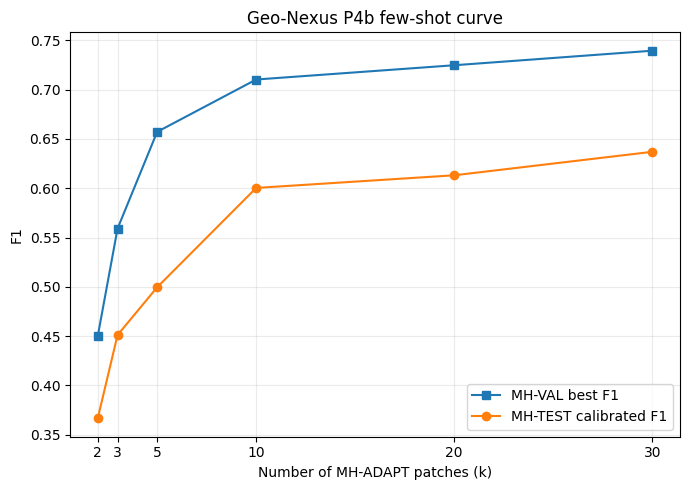

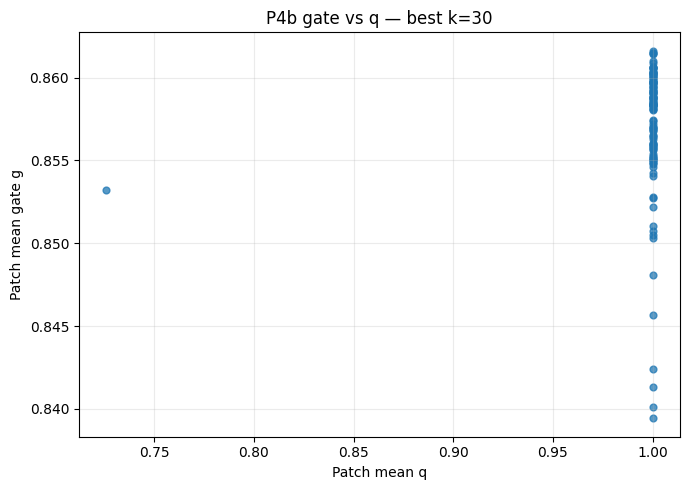

Per-zone results: /kaggle/working/geonexus_p4b_mh_v6/p4b_best_k_per_zone.csv
K curve: /kaggle/working/geonexus_p4b_mh_v6/p4b_k_curve.png
Gate-vs-q: /kaggle/working/geonexus_p4b_mh_v6/p4b_gate_vs_q.png


In [11]:
# ============================================================
# CELL 11 — per-zone results, k curve, gate-vs-q diagnostic
# ============================================================

def evaluate_zone_subset(probs, zone, threshold, seed):
    idx=[i for i,m in enumerate(test_meta) if meta_zone(m)==zone]
    if not idx: raise ValueError(f'No test patches found for zone {zone}')
    return evaluate_prediction_set([probs[i] for i in idx],[test_labels_list[i] for i in idx],threshold,bootstrap=min(BOOTSTRAP_RESAMPLES,1000),seed=seed)

zone_rows=[]
for protocol,probs,thr in [(f'P4b_PFS_k{best_k}',best_test_prob,p4b_records[best_k]['best_val_threshold']),(f'P4b_PFS_k{best_k}_strict',best_test_prob,p3_threshold)]:
    for zone in ('pune','satara','vidarbha'):
        m=evaluate_zone_subset(probs,zone,thr,SEED+len(zone))
        zone_rows.append({'protocol':protocol,'zone':zone,'n_patches':expected_zone['MH-TEST'][zone],'threshold':float(thr),'f1':m['f1'],'iou':m['iou'],'precision':m['precision'],'recall':m['recall'],'average_precision':m['average_precision'],'f1_ci95':m['f1_ci95']})
ZONE_CSV=RUN_DIR/'p4b_best_k_per_zone.csv'
with ZONE_CSV.open('w',newline='',encoding='utf-8') as f:
    w=csv.DictWriter(f,fieldnames=['protocol','zone','n_patches','threshold','f1','iou','precision','recall','average_precision','f1_ci95']); w.writeheader(); w.writerows(zone_rows)

ks=list(K_VALUES); val_curve=[p4b_records[k]['best_val_f1'] for k in ks]; test_curve=[p4b_records[k]['test_calibrated']['f1'] for k in ks]
fig,ax=plt.subplots(figsize=(7,5)); ax.plot(ks,val_curve,marker='s',label='MH-VAL best F1'); ax.plot(ks,test_curve,marker='o',label='MH-TEST calibrated F1'); ax.set_xlabel('Number of MH-ADAPT patches (k)'); ax.set_ylabel('F1'); ax.set_title('Geo-Nexus P4b few-shot curve'); ax.set_xticks(ks); ax.grid(True,alpha=0.25); ax.legend(); fig.tight_layout(); K_FIG=RUN_DIR/'p4b_k_curve.png'; fig.savefig(K_FIG,dpi=160,bbox_inches='tight'); plt.show(); plt.close(fig)
finite=np.isfinite(best_test_gate)&np.isfinite(best_test_q)
gate_q_corr=float(np.corrcoef(best_test_q[finite],best_test_gate[finite])[0,1]) if finite.sum()>=2 and np.std(best_test_q[finite])>0 and np.std(best_test_gate[finite])>0 else None
fig,ax=plt.subplots(figsize=(7,5)); ax.scatter(best_test_q[finite],best_test_gate[finite],s=24,alpha=0.75); ax.set_xlabel('Patch mean q'); ax.set_ylabel('Patch mean gate g'); ax.set_title(f'P4b gate vs q — best k={best_k}'); ax.grid(True,alpha=0.25); fig.tight_layout(); GATE_FIG=RUN_DIR/'p4b_gate_vs_q.png'; fig.savefig(GATE_FIG,dpi=160,bbox_inches='tight'); plt.show(); plt.close(fig)
print('Per-zone results:',ZONE_CSV); print('K curve:',K_FIG); print('Gate-vs-q:',GATE_FIG)


In [12]:
# ============================================================
# CELL 12 — final result tables and reproducible configuration
# ============================================================

summary_rows=[]
for k in K_VALUES:
    r=p4b_records[k]; m=r['test_calibrated']
    summary_rows.append({'protocol':'P4b_PFS','k':int(k),'best_epoch':int(r['best_epoch']),'val_f1':float(r['best_val_f1']),'threshold_from_val':float(r['best_val_threshold']),'test_precision':float(m['precision']),'test_recall':float(m['recall']),'test_f1':float(m['f1']),'test_iou':float(m['iou']),'test_average_precision':float(m['average_precision']),'test_kappa':float(m['kappa']),'test_f1_ci95':m['f1_ci95']})
RESULTS_JSON=RUN_DIR/'p4b_results.json'
RESULTS_PAYLOAD={'stage':'P4B_MH_FEWSHOT', 'revision':'V6', 'k_curve_extension':[2,3],'test_scope':'verified_partial_110','test_count':110,'zone_counts':expected_zone['MH-TEST'],'p3_threshold':float(p3_threshold),'best_k_by_mh_val_f1':int(best_k),'best_k_test_calibrated':{k:v for k,v in best_test_calibrated.items() if k!='patch_counts'},'best_k_test_strict':{k:v for k,v in best_test_strict.items() if k!='patch_counts'},'k_results':p4b_records,'configuration':{'k_values':list(K_VALUES),'batch_size':FS_BATCH_SIZE,'encoder_lr_optical':5e-6,'encoder_lr_sar':5e-6,'decoder_lr':2e-5,'gate_lr':1e-4,'gate_loss_weight':0.05,'deep_supervision':[1.0,0.5,0.25],'early_stop_patience':FS_PATIENCE,'max_epochs':FS_MAX_EPOCHS,'amp':AMP_ENABLED,'train_precision':('fp16' if AMP_ENABLED else 'fp32'),'seed':SEED,'label_ignore':IGNORE}}
RESULTS_JSON.write_text(json.dumps(RESULTS_PAYLOAD,indent=2),encoding='utf-8')
CSV_PATH=RUN_DIR/'p4b_results_summary.csv'
with CSV_PATH.open('w',newline='',encoding='utf-8') as f:
    writer=csv.DictWriter(f,fieldnames=list(summary_rows[0].keys())); writer.writeheader(); writer.writerows(summary_rows)
CONFIG_PATH=RUN_DIR/'p4b_config.json'; CONFIG_PATH.write_text(json.dumps(RESULTS_PAYLOAD['configuration'],indent=2),encoding='utf-8')
print('='*78); print('P4b FINAL RESULTS'); print('='*78)
print('Test scope: 110 = 40 Pune + 40 Satara + 30 Vidarbha')
print('Best k selected from MH-VAL:',best_k)
print('Best-k MH-VAL F1:',f'{p4b_records[best_k]["best_val_f1"]:.6f}')
print('Best-k threshold:',f'{p4b_records[best_k]["best_val_threshold"]:.2f}')
print('Best-k MH-TEST F1:',f'{best_test_calibrated["f1"]:.6f}')
print('Best-k MH-TEST IoU:',f'{best_test_calibrated["iou"]:.6f}')
print('Best-k MH-TEST AP:',f'{best_test_calibrated["average_precision"]:.6f}')
print('Gate-vs-q correlation:', 'undefined' if gate_q_corr is None else f'{gate_q_corr:.4f}')
print()
for row in summary_rows:
    print(f'k={row["k"]:2d} | val F1={row["val_f1"]:.6f}@{row["threshold_from_val"]:.2f} | test F1={row["test_f1"]:.6f} | IoU={row["test_iou"]:.6f} | AP={row["test_average_precision"]:.6f}')


P4b FINAL RESULTS
Test scope: 110 = 40 Pune + 40 Satara + 30 Vidarbha
Best k selected from MH-VAL: 30
Best-k MH-VAL F1: 0.739416
Best-k threshold: 0.28
Best-k MH-TEST F1: 0.636911
Best-k MH-TEST IoU: 0.467256
Best-k MH-TEST AP: 0.699565
Gate-vs-q correlation: 0.0817

k= 2 | val F1=0.450035@0.05 | test F1=0.366667 | IoU=0.224490 | AP=0.498098
k= 3 | val F1=0.559080@0.05 | test F1=0.451148 | IoU=0.291279 | AP=0.538602
k= 5 | val F1=0.657146@0.05 | test F1=0.499566 | IoU=0.332948 | AP=0.551054
k=10 | val F1=0.710217@0.16 | test F1=0.600291 | IoU=0.428869 | AP=0.656899
k=20 | val F1=0.724687@0.18 | test F1=0.613108 | IoU=0.442073 | AP=0.682786
k=30 | val F1=0.739416@0.28 | test F1=0.636911 | IoU=0.467256 | AP=0.699565


In [13]:
# ============================================================
# CELL 13 — final artifact integrity and safe cleanup
# ============================================================

def file_sha256(path):
    h=hashlib.sha256()
    with open(path,'rb') as f:
        for block in iter(lambda:f.read(1024*1024),b''):
            h.update(block)
    return h.hexdigest()

expected_outputs={'p4b_results.json','p4b_results_summary.csv','p4b_config.json','p4b_k_curve.png','p4b_gate_vs_q.png','p4b_best_k_per_zone.csv','p4b_k_subset_manifest.json','p3_geonexus_model.py'}
for k in K_VALUES:
    expected_outputs.update({f'mh_fewshot_k{k}.pth',f'mh_fewshot_k{k}_history.json',f'mh_fewshot_k{k}_test_probs.npy',f'mh_fewshot_k{k}_test_gate.npy',f'mh_fewshot_k{k}_test_q.npy'})
missing_outputs=sorted(name for name in expected_outputs if not (RUN_DIR/name).is_file())
if missing_outputs:
    raise RuntimeError('Final P4b artifact gate failed; missing files:\n'+'\n'.join(missing_outputs))
for k in K_VALUES:
    prob=np.load(RUN_DIR/f'mh_fewshot_k{k}_test_probs.npy',mmap_mode='r')
    gate=np.load(RUN_DIR/f'mh_fewshot_k{k}_test_gate.npy',mmap_mode='r')
    qv=np.load(RUN_DIR/f'mh_fewshot_k{k}_test_q.npy',mmap_mode='r')
    if prob.shape != (110,PATCH,PATCH) or not np.isfinite(prob).all():
        raise RuntimeError(f'k={k}: saved probability artifact has wrong shape or non-finite values.')
    if gate.shape != (110,) or qv.shape != (110,) or not (np.isfinite(gate).all() and np.isfinite(qv).all()):
        raise RuntimeError(f'k={k}: saved gate/q diagnostics are invalid.')
# Validate every persisted checkpoint before publication.
for k in K_VALUES:
    persisted = torch.load(RUN_DIR/f'mh_fewshot_k{k}.pth', map_location='cpu', weights_only=False)
    check_state_dict_finite(persisted['model'], f'persisted k={k} checkpoint')
    del persisted

BEST_FS_CKPT=RUN_DIR/f'mh_fewshot_best_k{best_k}.pth'
shutil.copy2(RUN_DIR/f'mh_fewshot_k{best_k}.pth',BEST_FS_CKPT)

sha={p.name:{'bytes':p.stat().st_size,'sha256':file_sha256(p)} for p in sorted(RUN_DIR.iterdir()) if p.is_file() and p.name!='SHA256SUMS.json'}
SHA_PATH=RUN_DIR/'SHA256SUMS.json'
SHA_PATH.write_text(json.dumps(sha,indent=2),encoding='utf-8')
del best_test_prob,best_test_gate,best_test_q,best_model
gc.collect(); torch.cuda.empty_cache()
print('='*78); print('P4b FINAL SELF-TEST: PASS'); print('='*78)
print('All k runs completed:',list(K_VALUES)); print('Best k selected from MH-VAL only:',best_k); print('All required checkpoints/artifacts present:',len(expected_outputs)); print('255 handling: IGNORE'); print('P4b gate: ACTIVE/TRAINABLE'); print('SHA256 manifest:',SHA_PATH); print('Best checkpoint:',BEST_FS_CKPT)


P4b FINAL SELF-TEST: PASS
All k runs completed: [2, 3, 5, 10, 20, 30]
Best k selected from MH-VAL only: 30
All required checkpoints/artifacts present: 38
255 handling: IGNORE
P4b gate: ACTIVE/TRAINABLE
SHA256 manifest: /kaggle/working/geonexus_p4b_mh_v6/SHA256SUMS.json
Best checkpoint: /kaggle/working/geonexus_p4b_mh_v6/mh_fewshot_best_k30.pth


In [14]:
# ============================================================
# CELL 14 — FINAL KAGGLE NOTEBOOK OUTPUT RELEASE PACKAGE
# ============================================================
#
# IMPORTANT:
# This cell intentionally does NOT call `kaggle datasets create`.
# Kaggle officially supports creating a Dataset directly from a
# saved Notebook version's Output files. This cell prepares and
# audits those output files so the rendered notebook can use:
#
#     Output -> Create Dataset
#
# without a second upload/API path.

from pathlib import Path
import json
import shutil
import hashlib
from datetime import datetime

# Fresh output directory for the exact files that should become
# the Kaggle Dataset.
OUTPUT_DIR = Path("/kaggle/working/P4b_Kaggle_Dataset_Ready")

if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True)

# Every completed k has a checkpoint + history + test probabilities
# + test gate + test q. Add the shared reproducibility artifacts.
release_files = []

for k in K_VALUES:
    release_files.extend([
        f"mh_fewshot_k{k}.pth",
        f"mh_fewshot_k{k}_history.json",
        f"mh_fewshot_k{k}_test_probs.npy",
        f"mh_fewshot_k{k}_test_gate.npy",
        f"mh_fewshot_k{k}_test_q.npy",
    ])

release_files.extend([
    f"mh_fewshot_best_k{best_k}.pth",
    "p4b_results.json",
    "p4b_results_summary.csv",
    "p4b_config.json",
    "p4b_best_k_per_zone.csv",
    "p4b_k_curve.png",
    "p4b_gate_vs_q.png",
    "p4b_k_subset_manifest.json",
    "p3_geonexus_model.py",
    "SHA256SUMS.json",
])

# De-duplicate while preserving order.
release_files = list(dict.fromkeys(release_files))

missing = [
    name for name in release_files
    if not (RUN_DIR / name).is_file()
]

if missing:
    raise RuntimeError(
        "Cannot prepare Kaggle output release. Missing artifacts:\n"
        + "\n".join(missing)
    )

# Copy all model/result artifacts.
for name in release_files:
    shutil.copy2(RUN_DIR / name, OUTPUT_DIR / name)

# Notebook-output release metadata (not used by Kaggle CLI; kept
# as an auditable project artifact).
release_metadata = {
    "release_name": "Geo-Nexus P4b Maharashtra Few-Shot Final",
    "revision": "V6",
    "dataset_id_target": "sumit07125/geonexus-p4b-mh-fewshot-final",
    "source_datasets": [
        "sumit07125/geonexus-p3-oscd-artifacts",
        "sumit07125/geonexus-mh-p4-eval-v3-2",
    ],
    "test_scope": {
        "total": 110,
        "pune": 40,
        "satara": 40,
        "vidarbha": 30,
    },
    "mh_adapt_count": 30,
    "mh_val_count": 30,
    "k_values": [int(k) for k in K_VALUES],
    "best_k_selected_from": "MH-VAL only",
    "best_k": int(best_k),
    "ignore_label": 255,
    "training_precision": "FP32",
    "inference_policy": "GPU FP32 with per-batch CPU float64 fallback if non-finite",
    "creation_workflow": "Kaggle Notebook Output -> Create Dataset",
    "created_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",
}

(OUTPUT_DIR / "P4b_release_metadata.json").write_text(
    json.dumps(release_metadata, indent=2),
    encoding="utf-8",
)

# Human-readable release README.
readme = f"""# Geo-Nexus v3.2 — P4b Maharashtra Few-Shot Release

Revision: V6

## Evaluation inputs
- P3: `sumit07125/geonexus-p3-oscd-artifacts`
- P4 evaluation source: `sumit07125/geonexus-mh-p4-eval-v3-2`

## Verified labelled scope
- MH-ADAPT: 30 patches
- MH-VAL: 30 patches
- MH-TEST: 110 patches (40 Pune + 40 Satara + 30 Vidarbha)
- Label 255: ignore

## Few-shot curve
k = {", ".join(str(k) for k in K_VALUES)}

The original V5 points were k=5,10,20,30. V6 adds k=2 and k=3 as low-shot
extensions while keeping the frozen 30-patch MH-ADAPT split intact.

## Numerical policy
- FP32 optimization
- finite gradient/parameter/buffer checks
- GPU FP32 inference
- exact CPU float64 fallback for non-finite GPU inference batches
- no NaN/Inf imputation

## Best-k rule
The best k is selected from MH-VAL F1 only. MH-TEST is reported only after
the selected checkpoint is restored.

## Included artifacts
All six k checkpoints, histories, test probabilities, gate/q diagnostics,
results tables, k-curve figure, gate-vs-q figure, subset manifest, P3 model
source, SHA256 manifest, and release metadata.
"""
(OUTPUT_DIR / "P4b_RELEASE_README.md").write_text(readme, encoding="utf-8")

# Build a fresh manifest over the release artifacts, excluding the manifest itself.
def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()

manifest = {}
for path in sorted(OUTPUT_DIR.iterdir()):
    if not path.is_file():
        continue
    if path.name == "P4b_RELEASE_MANIFEST.json":
        continue
    manifest[path.name] = {
        "bytes": int(path.stat().st_size),
        "sha256": sha256_file(path),
    }

(OUTPUT_DIR / "P4b_RELEASE_MANIFEST.json").write_text(
    json.dumps(manifest, indent=2),
    encoding="utf-8",
)

# Final self-audit.
all_output_files = sorted(
    p for p in OUTPUT_DIR.iterdir()
    if p.is_file()
)

total_output_bytes = sum(p.stat().st_size for p in all_output_files)
max_notebook_output_bytes = 20 * 1024**3
if total_output_bytes > max_notebook_output_bytes:
    raise RuntimeError(
        f'Notebook output release is too large: {total_output_bytes / 1024**3:.3f} GiB '
        f'> 20 GiB supported output limit.'
    )

expected_checkpoint_names = [
    f"mh_fewshot_k{k}.pth" for k in K_VALUES
]
expected_checkpoint_names.append(f"mh_fewshot_best_k{best_k}.pth")

missing_after_copy = [
    name for name in expected_checkpoint_names
    if not (OUTPUT_DIR / name).is_file()
]

if missing_after_copy:
    raise RuntimeError(
        "Notebook-output release self-test failed; missing checkpoints:\n"
        + "\n".join(missing_after_copy)
    )

print("=" * 78)
print("P4b KAGGLE NOTEBOOK OUTPUT RELEASE: PASS")
print("=" * 78)
print("Output directory :", OUTPUT_DIR)
print("K values         :", K_VALUES)
print("Best k           :", best_k)
print("Checkpoint files :", len(expected_checkpoint_names))
print("Total output files:", len(all_output_files))
print("Total output size :", f'{total_output_bytes / (1024**2):.2f} MiB')
print("Best checkpoint  :", OUTPUT_DIR / f"mh_fewshot_best_k{best_k}.pth")
print("Manifest         :", OUTPUT_DIR / "P4b_RELEASE_MANIFEST.json")
print()
print("NEXT KAGGLE UI STEP:")
print("1) Save Version -> Save & Run All with notebook output enabled.")
print("2) Open the rendered version -> Output -> Create Dataset.")
print("3) Select the files under P4b_Kaggle_Dataset_Ready.")
print("4) Create the private dataset with your desired Dataset title/slug.")


/tmp/ipykernel_58/3787683526.py:98: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_utc": datetime.utcnow().isoformat(timespec="seconds") + "Z",


P4b KAGGLE NOTEBOOK OUTPUT RELEASE: PASS
Output directory : /kaggle/working/P4b_Kaggle_Dataset_Ready
K values         : (2, 3, 5, 10, 20, 30)
Best k           : 30
Checkpoint files : 7
Total output files: 43
Total output size : 716.69 MiB
Best checkpoint  : /kaggle/working/P4b_Kaggle_Dataset_Ready/mh_fewshot_best_k30.pth
Manifest         : /kaggle/working/P4b_Kaggle_Dataset_Ready/P4b_RELEASE_MANIFEST.json

NEXT KAGGLE UI STEP:
1) Save Version -> Save & Run All with notebook output enabled.
2) Open the rendered version -> Output -> Create Dataset.
3) Select the files under P4b_Kaggle_Dataset_Ready.
4) Create the private dataset with your desired Dataset title/slug.


## Final Kaggle publication workflow

This notebook intentionally stops at a **fully audited Notebook Output release**. Kaggle's documented workflow supports creating a Dataset directly from a saved Notebook version's Output files; that avoids the title-collision failure encountered by direct API creation from this notebook. citeturn951549search0turn951549search7

After **Save Version → Save & Run All**, open the rendered notebook's **Output** tab and choose **Create Dataset**. Select the contents of:

`/kaggle/working/P4b_Kaggle_Dataset_Ready/`

The package contains all six k checkpoints:

`k = {2, 3, 5, 10, 20, 30}`

and the shared results, source, diagnostics, release metadata, README, and SHA256 manifest.

The current Notebook Output limit is 20 GB, which is comfortably above this release's size. citeturn951549search7


In [15]:
# ============================================================
# FINAL CELL — release inventory and integrity summary
# ============================================================

from pathlib import Path
import json
import hashlib
import re

OUTPUT_DIR = Path("/kaggle/working/P4b_Kaggle_Dataset_Ready")
MANIFEST_PATH = OUTPUT_DIR / "P4b_RELEASE_MANIFEST.json"

if not OUTPUT_DIR.is_dir():
    raise RuntimeError(f"Release output directory missing: {OUTPUT_DIR}")

if not MANIFEST_PATH.is_file():
    raise RuntimeError(f"Release manifest missing: {MANIFEST_PATH}")

manifest = json.loads(
    MANIFEST_PATH.read_text(encoding="utf-8")
)

if not isinstance(manifest, dict):
    raise RuntimeError("Release manifest must contain a JSON object.")


# ------------------------------------------------------------
# SHA256 verification
# ------------------------------------------------------------

def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)

    return h.hexdigest()


bad = []

for name, info in manifest.items():

    path = OUTPUT_DIR / name

    if not path.is_file():
        bad.append(f"missing: {name}")
        continue

    if not isinstance(info, dict):
        bad.append(f"invalid manifest entry: {name}")
        continue

    if "bytes" not in info or "sha256" not in info:
        bad.append(f"incomplete manifest entry: {name}")
        continue

    if path.stat().st_size != int(info["bytes"]):
        bad.append(f"size mismatch: {name}")
        continue

    actual_sha256 = sha256_file(path)

    if actual_sha256 != str(info["sha256"]):
        bad.append(f"sha256 mismatch: {name}")


if bad:
    raise RuntimeError(
        "Final release integrity check failed:\n"
        + "\n".join(bad)
    )


# ------------------------------------------------------------
# Checkpoint inventory
#
# IMPORTANT:
# Do NOT sort checkpoint filenames as strings.
# k=10 would otherwise appear before k=2.
#
# Extract the numeric k value and sort numerically.
# ------------------------------------------------------------

checkpoint_pattern = re.compile(
    r"^mh_fewshot_k(\d+)\.pth$"
)

checkpoint_pairs = []

for p in OUTPUT_DIR.iterdir():

    if not p.is_file():
        continue

    match = checkpoint_pattern.fullmatch(p.name)

    if match is not None:
        k_value = int(match.group(1))
        checkpoint_pairs.append((k_value, p.name))


# Numeric ordering: 2, 3, 5, 10, 20, 30
checkpoint_pairs.sort(key=lambda item: item[0])

checkpoint_k_values = [
    k for k, _ in checkpoint_pairs
]

checkpoints = [
    name for _, name in checkpoint_pairs
]


# ------------------------------------------------------------
# Expected V6 checkpoint inventory
# ------------------------------------------------------------

expected_k_values = [2, 3, 5, 10, 20, 30]

expected_checkpoints = [
    f"mh_fewshot_k{k}.pth"
    for k in expected_k_values
]


# First verify numeric k inventory
if checkpoint_k_values != expected_k_values:
    raise RuntimeError(
        "Checkpoint inventory mismatch.\n"
        f"Expected k values: {expected_k_values}\n"
        f"Found k values   : {checkpoint_k_values}"
    )


# Then verify exact filenames
if checkpoints != expected_checkpoints:
    raise RuntimeError(
        "Checkpoint filename inventory mismatch.\n"
        f"Expected: {expected_checkpoints}\n"
        f"Found   : {checkpoints}"
    )


# ------------------------------------------------------------
# Best-k checkpoint
# ------------------------------------------------------------

best_candidates = sorted(
    p.name
    for p in OUTPUT_DIR.glob("mh_fewshot_best_k*.pth")
    if p.is_file()
)

if len(best_candidates) != 1:
    raise RuntimeError(
        "Expected exactly one best-k checkpoint, "
        f"found {len(best_candidates)}: {best_candidates}"
    )


best_match = re.fullmatch(
    r"mh_fewshot_best_k(\d+)\.pth",
    best_candidates[0]
)

if best_match is None:
    raise RuntimeError(
        f"Best checkpoint has an invalid filename: "
        f"{best_candidates[0]}"
    )

best_k = int(best_match.group(1))

if best_k not in expected_k_values:
    raise RuntimeError(
        f"Best checkpoint k={best_k} is not one of the "
        f"expected k values: {expected_k_values}"
    )


# ------------------------------------------------------------
# Final success report
# ------------------------------------------------------------

print("=" * 78)
print("FINAL KAGGLE OUTPUT INTEGRITY: PASS")
print("=" * 78)

print("Checkpoint artifacts :", checkpoints)
print("Checkpoint k values  :", checkpoint_k_values)
print("Checkpoint count     :", len(checkpoints))
print("Manifest entries     :", len(manifest))
print("Best checkpoint      :", best_candidates[0])
print("Best k               :", best_k)
print("All SHA256 checks    : PASS")
print()
print("Ready for Kaggle: Output -> Create Dataset")

FINAL KAGGLE OUTPUT INTEGRITY: PASS
Checkpoint artifacts : ['mh_fewshot_k2.pth', 'mh_fewshot_k3.pth', 'mh_fewshot_k5.pth', 'mh_fewshot_k10.pth', 'mh_fewshot_k20.pth', 'mh_fewshot_k30.pth']
Checkpoint k values  : [2, 3, 5, 10, 20, 30]
Checkpoint count     : 6
Manifest entries     : 42
Best checkpoint      : mh_fewshot_best_k30.pth
Best k               : 30
All SHA256 checks    : PASS

Ready for Kaggle: Output -> Create Dataset
